In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

df = pd.read_csv('/content/product_sales_clean.csv')
customers = pd.read_csv('/content/customer_segmentation.csv')

In [ ]:
df.head()

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit,Customer_ID,Customer_ID_Numeric
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,"Bianca Brown | Jackson, Mississippi",0
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09,"Jared Edwards | Grand Rapids, Michigan",1
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,"Susan Valdez | Minneapolis, Minnesota",2
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38,"Tina Williams | Tallahassee, Florida",3
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,"Catherine Gordon | Baltimore, Maryland",4


In [ ]:
# Convertir fecha a datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Definir "hoy" como última fecha en el dataset
today = df['Order_Date'].max()
print(f"Fecha de referencia (última compra en dataset): {today.date()}")

Fecha de referencia (última compra en dataset): 2024-12-31


/tmp/ipykernel_1339/292965932.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])


1. CREAR TABLA DE CLIENTES

In [ ]:
customers = df.groupby('Customer_ID_Numeric').agg({
    'Customer_Name': 'first',
    'City': 'first',
    'State': 'first',
    'Region': 'first',
    'Order_Date': ['min', 'max', 'count'],
    'Revenue': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'  # Categoría más frecuente
}).reset_index()

# Aplanar nombres de columnas
customers.columns = ['Customer_ID_Numeric', 'Customer_Name', 'City', 'State', 'Region',
                     'First_Purchase', 'Last_Purchase', 'Num_Orders',
                     'Total_Revenue', 'Total_Profit', 'Total_Quantity', 'Primary_Category']

print(f"Total de clientes únicos: {len(customers):,}")

Total de clientes únicos: 197,000


In [ ]:
customers.head()

,Customer_ID_Numeric,Customer_Name,City,State,Region,First_Purchase,Last_Purchase,Num_Orders,Total_Revenue,Total_Profit,Total_Quantity,Primary_Category
0,0,Bianca Brown,Jackson,Mississippi,South,2023-08-23,2023-08-23,1,603.03,221.49,3,Accessories
1,1,Jared Edwards,Grand Rapids,Michigan,Centre,2024-12-20,2024-12-20,1,297.20,97.09,4,Accessories
2,2,Susan Valdez,Minneapolis,Minnesota,Centre,2024-01-29,2024-01-29,1,68.19,25.47,1,Clothing & Apparel
3,3,Tina Williams,Tallahassee,Florida,South,2024-11-29,2024-11-29,1,628.92,231.38,3,Clothing & Apparel
4,4,Catherine Gordon,Baltimore,Maryland,East,2023-09-21,2023-09-21,1,216.63,42.46,1,Accessories


2. CALCULAR RECENCY Y MONETARY

In [ ]:
# Recency: días desde última compra hasta "hoy"
customers['Recency_Days'] = (today - customers['Last_Purchase']).dt.days

# Monetary: total gastado
customers['Monetary'] = customers['Total_Revenue']

# Valor promedio por orden
customers['Avg_Order_Value'] = customers['Total_Revenue'] / customers['Num_Orders']
# Ganancia promedio por orden
customers['Avg_Profit_Per_Order'] = customers['Total_Profit'] / customers['Num_Orders']

print(f"\nRecency (días desde última compra):")
print(customers['Recency_Days'].describe())
print(f"\nMonetary (revenue total por cliente):")
print(customers['Monetary'].describe())


Recency (días desde última compra):
count    197000.000000
mean        321.342310
std         211.873852
min           0.000000
25%         107.000000
50%         360.000000
75%         473.000000
max         730.000000
Name: Recency_Days, dtype: float64

Monetary (revenue total por cliente):
count    197000.000000
mean        722.881954
std         753.634617
min          17.030000
25%         231.560000
50%         471.975000
75%         893.340000
max        9014.250000
Name: Monetary, dtype: float64


3. SCORING R Y M (1-5 SCALE)

In [ ]:
# R_Score: Más reciente = score más alto
# Dividir en quintiles
customers['R_Score'] = pd.qcut(customers['Recency_Days'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

# M_Score: Más gasto = score más alto
customers['M_Score'] = pd.qcut(customers['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

print(f"\nDistribución de R_Score:")
print(customers['R_Score'].value_counts().sort_index(ascending=False))
print(f"\nDistribución de M_Score:")
print(customers['M_Score'].value_counts().sort_index())


Distribución de R_Score:
R_Score
5    39598
4    39217
3    39443
2    39397
1    39345
Name: count, dtype: int64

Distribución de M_Score:
M_Score
1    39401
2    39399
3    39401
4    39399
5    39400
Name: count, dtype: int64


4. CREAR SEGMENTOS (R × M)

In [ ]:
def segment_customer(r_score, m_score):
    """Asignar segmento basado en R y M scores"""
    if r_score >= 4 and m_score >= 4:
        return 'Champions'
    elif r_score >= 4 and m_score >= 2:
        return 'Potential'
    elif r_score <= 2 and m_score >= 4:
        return 'High_Value'
    elif r_score <= 2 and m_score <= 2:
        return 'Lost'
    elif r_score >= 3 and m_score >= 3:
        return 'Loyal'
    else:
        return 'At_Risk'

# Aplico la regmentacion a todos los clientes (axis=1 es para fila por fila)
customers['Segment'] = customers.apply(
    lambda row: segment_customer(row['R_Score'], row['M_Score']),
    axis=1
)

print(f"\nDistribución de segmentos:")
segment_dist = customers['Segment'].value_counts()
for seg, count in segment_dist.items():
    pct = (count / len(customers)) * 100
    print(f"  {seg:15} : {count:6,} clientes ({pct:5.1f}%)")


Distribución de segmentos:
  At_Risk         : 47,013 clientes ( 23.9%)
  Champions       : 31,924 clientes ( 16.2%)
  Lost            : 31,904 clientes ( 16.2%)
  Potential       : 31,339 clientes ( 15.9%)
  High_Value      : 31,083 clientes ( 15.8%)
  Loyal           : 23,737 clientes ( 12.0%)


In [ ]:
customers.head()

,Customer_ID_Numeric,Customer_Name,City,State,Region,First_Purchase,Last_Purchase,Num_Orders,Total_Revenue,Total_Profit,Total_Quantity,Primary_Category,Recency_Days,Monetary,Avg_Order_Value,Avg_Profit_Per_Order,R_Score,M_Score,Segment
0,0,Bianca Brown,Jackson,Mississippi,South,2023-08-23,2023-08-23,1,603.03,221.49,3,Accessories,496,603.03,603.03,221.49,2,3,At_Risk
1,1,Jared Edwards,Grand Rapids,Michigan,Centre,2024-12-20,2024-12-20,1,297.20,97.09,4,Accessories,11,297.20,297.20,97.09,5,2,Potential
2,2,Susan Valdez,Minneapolis,Minnesota,Centre,2024-01-29,2024-01-29,1,68.19,25.47,1,Clothing & Apparel,337,68.19,68.19,25.47,3,1,At_Risk
3,3,Tina Williams,Tallahassee,Florida,South,2024-11-29,2024-11-29,1,628.92,231.38,3,Clothing & Apparel,32,628.92,628.92,231.38,5,3,Potential
4,4,Catherine Gordon,Baltimore,Maryland,East,2023-09-21,2023-09-21,1,216.63,42.46,1,Accessories,467,216.63,216.63,42.46,2,2,Lost


5. ANÁLISIS POR SEGMENTO

In [ ]:
segment_analysis = customers.groupby('Segment').agg({
    'Customer_ID_Numeric': 'count',
    'Total_Revenue': ['sum', 'mean'],
    'Total_Profit': ['sum', 'mean'],
    'Avg_Order_Value': 'mean',
    'Recency_Days': 'mean',
    'Primary_Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A' # categoria principal de cada segmento, si no hay moda asigna N/A
}).round(2)

segment_analysis.columns = ['Num_Customers', 'Total_Revenue', 'Avg_Revenue',
                             'Total_Profit', 'Avg_Profit', 'Avg_Order_Value',
                             'Avg_Recency_Days', 'Most_Common_Category']

segment_analysis = segment_analysis.sort_values('Avg_Revenue', ascending=False)
print(segment_analysis)

            Num_Customers  Total_Revenue  Avg_Revenue  Total_Profit  \
Segment                                                               
Champions           31924    43780854.93      1371.41    8964189.48   
High_Value          31083    42231544.65      1358.67    8634821.57   
Loyal               23737    25438899.99      1071.70    5420821.31   
Potential           31339    11930646.90       380.70    3202787.79   
At_Risk             47013    12666018.58       269.42    3455283.05   
Lost                31904     6359779.88       199.34    1870704.93   

            Avg_Profit  Avg_Order_Value  Avg_Recency_Days Most_Common_Category  
Segment                                                                         
Champions       280.80          1331.42             96.73          Electronics  
High_Value      277.80          1347.90            534.92          Electronics  
Loyal           228.37          1053.48            343.58          Electronics  
Potential       102.20    

6. ANÁLISIS DE CATEGORÍA POR SEGMENTO

In [ ]:
for segment in customers['Segment'].unique():
    segment_data = df[df['Customer_ID_Numeric'].isin(customers[customers['Segment'] == segment]['Customer_ID_Numeric'])]
    category_breakdown = segment_data.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

    print(f"\n{segment}:")
    for cat, rev in category_breakdown.head(5).items():
        pct = (rev / category_breakdown.sum()) * 100
        print(f"  {cat:30} : ${rev:10,.0f} ({pct:5.1f}%)")


At_Risk:
  Clothing & Apparel             : $ 4,455,209 ( 35.2%)
  Accessories                    : $ 2,938,619 ( 23.2%)
  Home & Furniture               : $ 2,840,187 ( 22.4%)
  Electronics                    : $ 2,432,004 ( 19.2%)

Potential:
  Clothing & Apparel             : $ 4,449,581 ( 37.3%)
  Home & Furniture               : $ 2,805,374 ( 23.5%)
  Electronics                    : $ 2,479,797 ( 20.8%)
  Accessories                    : $ 2,195,895 ( 18.4%)

Lost:
  Clothing & Apparel             : $ 2,713,572 ( 42.7%)
  Accessories                    : $ 1,926,977 ( 30.3%)
  Home & Furniture               : $   952,789 ( 15.0%)
  Electronics                    : $   766,442 ( 12.1%)

Champions:
  Electronics                    : $20,746,032 ( 47.4%)
  Home & Furniture               : $16,160,742 ( 36.9%)
  Clothing & Apparel             : $ 5,873,665 ( 13.4%)
  Accessories                    : $ 1,000,416 (  2.3%)

High_Value:
  Electronics                    : $19,947,279 ( 4

7. OPORTUNIDADES DE CROSS-SELL

In [ ]:
# Crear lista de categorías por cliente
customer_categories = df.groupby('Customer_ID_Numeric')['Category'].apply(list).reset_index()
customer_categories['Num_Categories'] = customer_categories['Category'].apply(lambda x: len(set(x))) # elimina duplicador por si un cliente compro mas de una vez una misma categoria

# Unir tablar categories a los segmentos de customers
customer_categories = customer_categories.merge(customers[['Customer_ID_Numeric', 'Segment']], on='Customer_ID_Numeric')

# Analizar los 3 segmentos mas valiosos
for segment in ['Champions', 'High_Value', 'Potential']:
    segment_cats = customer_categories[customer_categories['Segment'] == segment]
    single_cat_pct = (segment_cats['Num_Categories'] == 1).sum() / len(segment_cats) * 100
    multi_cat_pct = (segment_cats['Num_Categories'] > 1).sum() / len(segment_cats) * 100

    print(f"\n{segment}:")
    print(f"  Compran solo 1 categoría: {single_cat_pct:.1f}% → Oportunidad de cross-sell")
    print(f"  Compran múltiples categorías: {multi_cat_pct:.1f}% → Ya diversificados")


Champions:
  Compran solo 1 categoría: 96.6% → Oportunidad de cross-sell
  Compran múltiples categorías: 3.4% → Ya diversificados

High_Value:
  Compran solo 1 categoría: 99.1% → Oportunidad de cross-sell
  Compran múltiples categorías: 0.9% → Ya diversificados

Potential:
  Compran solo 1 categoría: 99.2% → Oportunidad de cross-sell
  Compran múltiples categorías: 0.8% → Ya diversificados


8. GUARDAR RESULTADOS

In [ ]:
# Tabla completa de clientes con segmento
customers_with_segment = customers[[
    'Customer_ID_Numeric', 'Customer_Name', 'City', 'State', 'Region',
    'Last_Purchase', 'Recency_Days', 'Num_Orders', 'Total_Revenue', 'Total_Profit',
    'Avg_Order_Value', 'Primary_Category',
    'R_Score', 'M_Score', 'Segment'
]]

customers_with_segment.to_csv('customer_segmentation.csv', index=False)
print("Guardado: customer_segmentation.csv")

segment_analysis.to_csv('segment_analysis.csv')
print("Guardado: segment_analysis.csv")

In [ ]:
customers_with_segment.head()

,Customer_ID_Numeric,Customer_Name,City,State,Region,Last_Purchase,Recency_Days,Num_Orders,Total_Revenue,Total_Profit,Avg_Order_Value,Primary_Category,R_Score,M_Score,Segment
0,0,Bianca Brown,Jackson,Mississippi,South,2023-08-23,496,1,603.03,221.49,603.03,Accessories,2,3,At_Risk
1,1,Jared Edwards,Grand Rapids,Michigan,Centre,2024-12-20,11,1,297.20,97.09,297.20,Accessories,5,2,Potential
2,2,Susan Valdez,Minneapolis,Minnesota,Centre,2024-01-29,337,1,68.19,25.47,68.19,Clothing & Apparel,3,1,At_Risk
3,3,Tina Williams,Tallahassee,Florida,South,2024-11-29,32,1,628.92,231.38,628.92,Clothing & Apparel,5,3,Potential
4,4,Catherine Gordon,Baltimore,Maryland,East,2023-09-21,467,1,216.63,42.46,216.63,Accessories,2,2,Lost


In [ ]:
segment_analysis.head()

,Num_Customers,Total_Revenue,Avg_Revenue,Total_Profit,Avg_Profit,Avg_Order_Value,Avg_Recency_Days,Most_Common_Category
Segment,,,,,,,,
Champions,31924,43780854.93,1371.41,8964189.48,280.80,1331.42,96.73,Electronics
High_Value,31083,42231544.65,1358.67,8634821.57,277.80,1347.90,534.92,Electronics
Loyal,23737,25438899.99,1071.70,5420821.31,228.37,1053.48,343.58,Electronics
Potential,31339,11930646.90,380.70,3202787.79,102.20,378.18,96.99,Clothing & Apparel
At_Risk,47013,12666018.58,269.42,3455283.05,73.50,268.89,326.43,Clothing & Apparel


9. VISUALIZACIONES

/tmp/ipykernel_1339/3243530956.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('segmentation_analysis.png', dpi=300, bbox_inches='tight')


✓ Guardado: segmentation_analysis.png


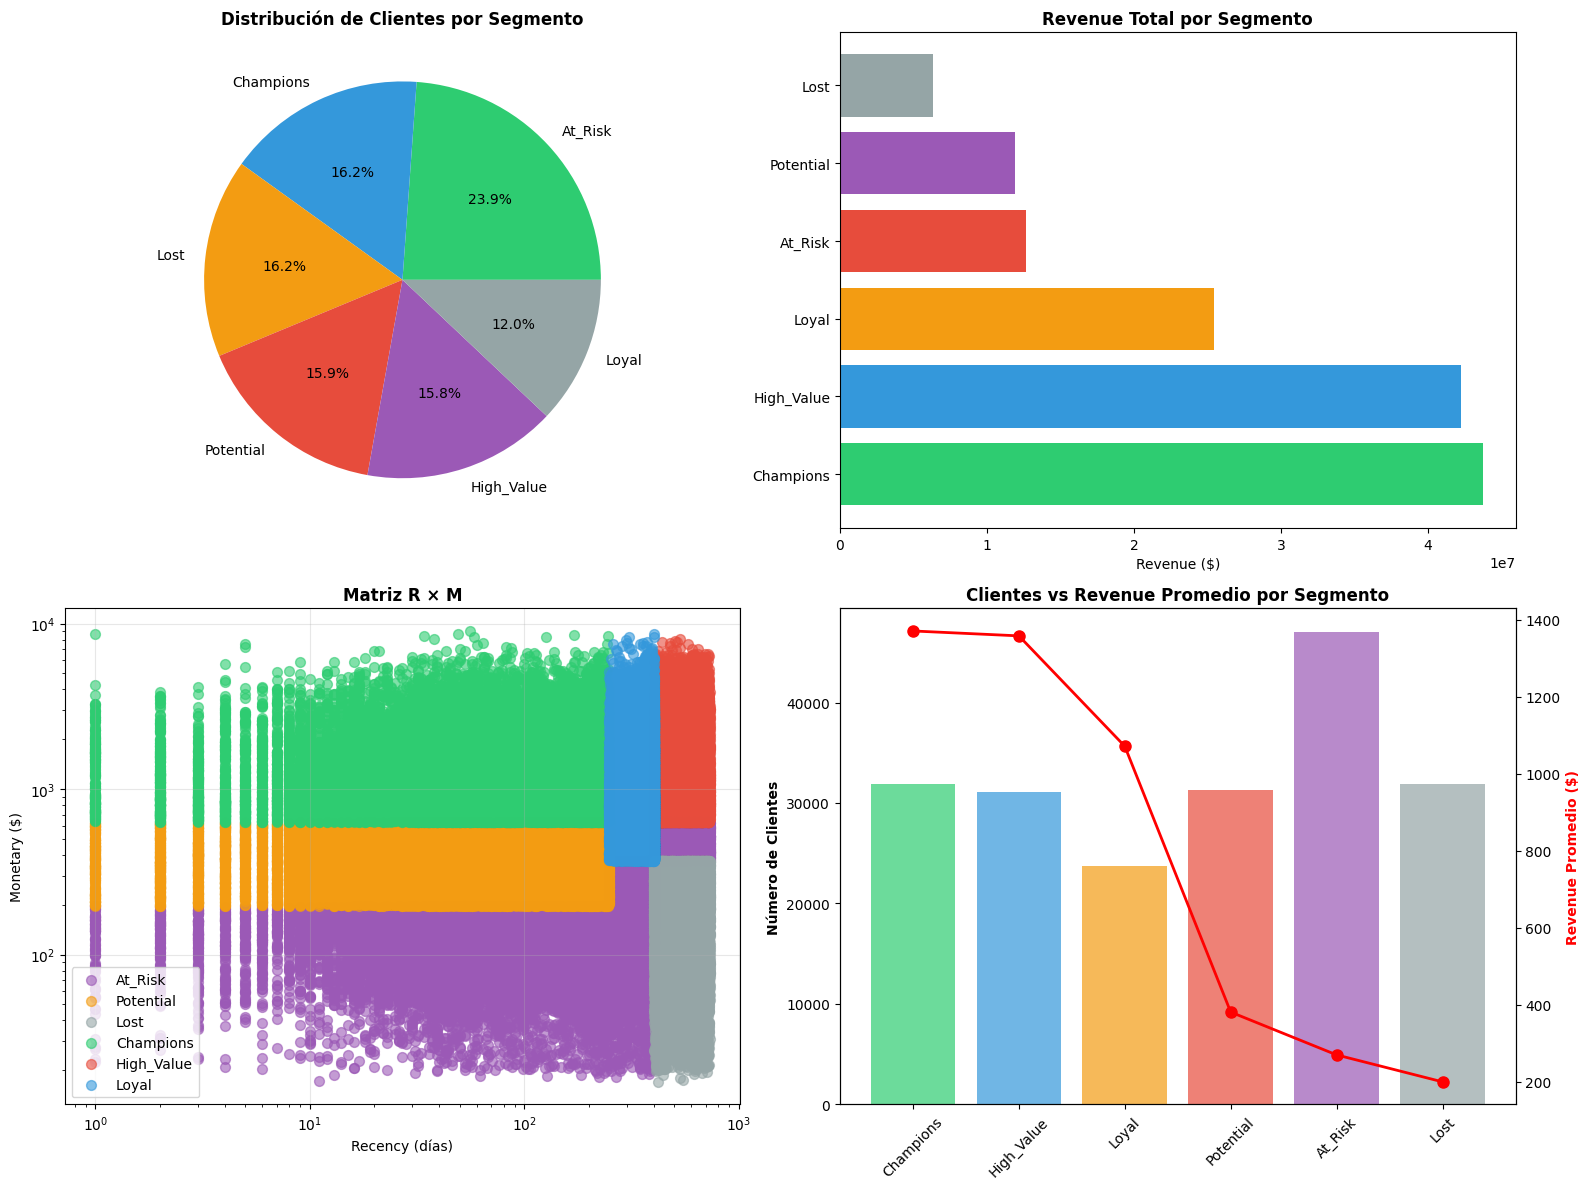

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de segmentos (pie chart)
segment_counts = customers['Segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#95a5a6']
axes[0, 0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors)
axes[0, 0].set_title('Distribución de Clientes por Segmento', fontsize=12, fontweight='bold')

# 2. Revenue por segmento
segment_revenue = customers.groupby('Segment')['Total_Revenue'].sum().sort_values(ascending=False)
axes[0, 1].barh(segment_revenue.index, segment_revenue.values, color=colors)
axes[0, 1].set_title('Revenue Total por Segmento', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Revenue ($)')

# 3. Matriz R × M (scatter plot)
scatter_colors = {'Champions': '#2ecc71', 'Loyal': '#3498db', 'Potential': '#f39c12',
                  'High_Value': '#e74c3c', 'At_Risk': '#9b59b6', 'Lost': '#95a5a6'}
for segment in customers['Segment'].unique():
    segment_data = customers[customers['Segment'] == segment]
    axes[1, 0].scatter(segment_data['Recency_Days'], segment_data['Total_Revenue'],
                      label=segment, alpha=0.6, s=50, color=scatter_colors.get(segment, '#000'))
axes[1, 0].set_xlabel('Recency (días)')
axes[1, 0].set_ylabel('Monetary ($)')
axes[1, 0].set_title('Matriz R × M', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# 4. Número de clientes vs revenue promedio por segmento
segment_stats = customers.groupby('Segment').agg({
    'Customer_ID_Numeric': 'count',
    'Total_Revenue': 'mean'
}).sort_values('Total_Revenue', ascending=False)

ax_twin = axes[1, 1].twinx()
bars = axes[1, 1].bar(segment_stats.index, segment_stats['Customer_ID_Numeric'], alpha=0.7, color=colors, label='# Clientes')
line = ax_twin.plot(segment_stats.index, segment_stats['Total_Revenue'], 'r-o', linewidth=2, markersize=8, label='Avg Revenue')

axes[1, 1].set_ylabel('Número de Clientes', fontweight='bold')
ax_twin.set_ylabel('Revenue Promedio ($)', fontweight='bold', color='r')
axes[1, 1].set_title('Clientes vs Revenue Promedio por Segmento', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('segmentation_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: segmentation_analysis.png")
plt.show()